<a href="https://colab.research.google.com/github/Arun110908/ai-health-report-analyzer/blob/main/notebooks/AI_Health_Report_Analyzer_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🩺 AI Health Report Analyzer & Personal Health Assistant
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Arun110908/ai-health-report-analyzer/blob/main/notebooks/AI_Health_Report_Analyzer_Demo.ipynb)

A multi-agent pipeline that turns a raw blood report (PDF / image / DOCX / text) into a simple, structured health summary.

| Agent | Job | Uses LLM? |
|---|---|---|
| **1. Report Processing** | OCR / text extraction, parameter parsing, name + unit normalisation, low/normal/high classification | No (deterministic) |
| **2. Medical Analysis** | Finds deficiencies and risks, explains abnormal values, health score | Claude (optional) + rule-based fallback |
| **3. Recommendation** | Diet, exercise, hydration, sleep, lifestyle, follow-up | Claude (optional) + rule-based fallback |
| **4. Report Generation** | Assembles the final structured report | No (deterministic) |

Orchestrated with **LangGraph**. Works **without any API key** (rule-based fallback); add `ANTHROPIC_API_KEY` in Colab Secrets to switch Agents 2 and 3 to Claude.

> ⚠️ Informational tool, **not a medical diagnosis**. All demo data here is synthetic.

**How to run:** Runtime → **Run all**. The first cell takes ~1-2 minutes (installs Tesseract + dependencies).

## 1. Setup

In [30]:
#@title Clone the repo and install dependencies { display-mode: "form" }
import os, shutil

REPO_URL = "https://github.com/Arun110908/ai-health-report-analyzer.git"
if not os.path.isdir("ai-health-report-analyzer") and not os.getcwd().endswith("ai-health-report-analyzer"):
    !git clone -q $REPO_URL
if not os.getcwd().endswith("ai-health-report-analyzer"):
    %cd ai-health-report-analyzer

if shutil.which("tesseract") is None:
    !apt-get -qq install -y tesseract-ocr poppler-utils > /dev/null

!pip install -q -r backend/requirements.txt
!pip install -q langchain-core>=1.6.0 langgraph>=1.2.11 # Explicitly install compatible versions
print("\n✅ Setup done (pip may print dependency-conflict warnings above; they are harmless here)")


✅ Setup done (pip may print dependency-conflict warnings above; they are harmless here)


## 2. Load the pipeline
Optional: add a Colab Secret named `ANTHROPIC_API_KEY` (🔑 icon in the left sidebar) to use Claude in Agents 2 and 3. **Never paste the key into a cell.**

In [31]:
import os, sys, re, glob
sys.path.insert(0, "backend")

try:
    from google.colab import userdata
    os.environ["ANTHROPIC_API_KEY"] = userdata.get("ANTHROPIC_API_KEY")
    print("🔑 Claude key loaded from Colab Secrets")
except Exception:
    print("ℹ️ No ANTHROPIC_API_KEY secret found -> rule-based mode (everything still works)")

from app.models import PipelineState
from app.pipeline import run_pipeline, using_langgraph
from app.llm_client import claude_client, MODEL_NAME

print("Pipeline engine:", "LangGraph" if using_langgraph() else "sequential fallback")
print("Claude enabled :", claude_client.available, f"({MODEL_NAME})")

ℹ️ No ANTHROPIC_API_KEY secret found -> rule-based mode (everything still works)
Pipeline engine: LangGraph
Claude enabled : False (claude-sonnet-4-6)


In [32]:
print('Upgrading langchain-core and langgraph to compatible versions...')
!pip install -q langchain-core>=1.6.0 langgraph>=1.2.11
print('✅ Upgrade complete.')

Upgrading langchain-core and langgraph to compatible versions...
✅ Upgrade complete.


The environment has been refreshed with the updated `langchain` libraries. You can now re-run the `analyze_text` function to see if the `AttributeError` is resolved.

In [33]:
import langchain

if hasattr(langchain, 'debug'):
    print("✅ 'langchain.debug' exists.")
else:
    print("❌ 'langchain.debug' does NOT exist.")

❌ 'langchain.debug' does NOT exist.


## 3. Helper functions (display, chart)

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

STATUS_COLOR = {"normal": "#2e7d32", "low": "#ef6c00", "high": "#ef6c00",
                "critical_low": "#c62828", "critical_high": "#c62828", "unknown": "#757575"}

def _color(col):
    return [f"color: {STATUS_COLOR.get(v, '#000')}; font-weight: bold" for v in col]

def parse_range(s):
    if not s:
        return None, None
    m = re.match(r"^\s*([\d.]+)\s*-\s*([\d.]+)\s*$", s)
    if m:
        return float(m.group(1)), float(m.group(2))
    m = re.match(r"^\s*<\s*([\d.]+)\s*$", s)
    if m:
        return None, float(m.group(1))
    m = re.match(r"^\s*>\s*([\d.]+)\s*$", s)
    if m:
        return float(m.group(1)), None
    return None, None

def plot_ranges(params):
    rows = []
    for p in params:
        lo, hi = parse_range(p.reference_range)
        if lo is None or hi is None or p.value is None or hi <= lo:
            continue
        pos = (p.value - lo) / (hi - lo)
        rows.append((p.name, max(min(pos, 1.7), -0.7), p.status))
    if not rows:
        return
    fig, ax = plt.subplots(figsize=(8, 0.38 * len(rows) + 1.2))
    ax.axvspan(0, 1, color="#c8e6c9", alpha=0.7)
    for i, (name, pos, status) in enumerate(rows):
        ax.scatter(pos, i, s=70, color=STATUS_COLOR.get(status, "#757575"), zorder=3)
    ax.set_yticks(range(len(rows)))
    ax.set_yticklabels([r[0] for r in rows])
    ax.invert_yaxis()
    ax.set_xlim(-0.8, 1.8)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["low limit", "high limit"])
    ax.set_title("Each value vs its normal range (green band = normal)")
    ax.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()

def analyze_text(text, file_type="text", ocr_confidence=1.0):
    return run_pipeline(PipelineState(raw_text=text, file_type=file_type, ocr_confidence=ocr_confidence))

def show(state):
    r = state.final_report
    if r is None:
        print("Pipeline failed:", state.errors)
        return
    display(Markdown(f"## Health score: **{r.overall_health_score}/100**\n\n{r.summary}"))
    if r.critical_alerts:
        display(Markdown("### 🚨 Critical alerts\n" + "\n".join(f"- {a}" for a in r.critical_alerts)))
    if r.doctor_consultation_suggested:
        display(Markdown(f"### 🩺 Doctor consultation suggested\n{r.doctor_consultation_reason or ''}"))
    df = pd.DataFrame([{"Parameter": p.name, "Value": p.value, "Unit": p.unit,
                        "Reference": p.reference_range, "Status": p.status} for p in r.parameters])
    display(df.style.apply(_color, subset=["Status"]).hide(axis="index"))
    plot_ranges(r.parameters)
    if r.deficiencies:
        display(Markdown("### Deficiencies\n" + "\n".join(f"- **{d.title}** ({d.severity}): {d.explanation}" for d in r.deficiencies)))
    if r.health_risks:
        display(Markdown("### Health risks\n" + "\n".join(f"- **{d.title}** ({d.severity}): {d.explanation}" for d in r.health_risks)))
    rec = r.recommendations
    for label, items in [("🥗 Eat", rec.diet_eat), ("🚫 Avoid", rec.diet_avoid), ("🏃 Exercise", rec.exercise),
                         ("💧 Hydration", rec.hydration), ("😴 Sleep", rec.sleep),
                         ("🧘 Stress", rec.stress_management), ("🌿 Lifestyle", rec.lifestyle)]:
        if items:
            display(Markdown(f"**{label}**\n" + "\n".join(f"- {i}" for i in items)))

def show_agents(state):
    e, a, rec, f = state.extracted, state.analysis, state.recommendations, state.final_report
    print("Agent 1 · Report Processing :", len(e.parameters), "parameters | format:", e.report_format_detected,
          "| OCR confidence:", e.ocr_confidence, "| warnings:", len(e.warnings))
    for w in e.warnings[:6]:
        print("      ⚠", w)
    print("Agent 2 · Medical Analysis  :", len(a.abnormal_parameters), "abnormal ->", a.abnormal_parameters,
          "| deficiencies:", len(a.deficiencies), "| risks:", len(a.health_risks))
    n = sum(len(x) for x in (rec.diet_eat, rec.diet_avoid, rec.exercise, rec.hydration,
                             rec.sleep, rec.stress_management, rec.lifestyle))
    print("Agent 3 · Recommendations   :", n, "recommendation items")
    print("Agent 4 · Report Generation : health score", f.overall_health_score,
          "| doctor consultation:", f.doctor_consultation_suggested)
print("✅ helpers ready")

✅ helpers ready


## 4. Demo: analyze a sample report
`backend/sample_data/` has 25 **synthetic** reports in 4 different layouts. Change the file name below to try others (`sample_report_01.txt` ... `sample_report_25.txt`).

In [35]:
#@title Pick a sample report { display-mode: "form" }
SAMPLE = "sample_report_03.txt" #@param {type:"string"}

text = open(f"backend/sample_data/{SAMPLE}").read()
print("\n".join(text.splitlines()[:22]))
print("   ...")

SUNRISE MEDICAL CENTRE
Laboratory Test Report
Patient Name: Priya Lakshmi
Age: 62 Years   Sex: Male
Sample Collected: 16/09/2025 08:35
Report Format Variant: 3
------------------------------------------------------------
Haemoglobin (Hb)                16.45  g/dL   13 - 17  
Total Leucocyte Count (TLC)     8,930  cells/cumm   4,000 - 11,000  
Platelet Count                  0.77  lakhs/cumm   1.5 - 4.5  L
Fasting Blood Sugar (FBS)       65.64  mg/dL   Ref: 70 - 99  L
HbA1c                           6.05  %   Ref: 4 - 5.6  H
Total Cholesterol               136.76  mg/dL   Desirable: <200  Borderline: 200-239  High: >=240
LDL Cholesterol                 121.2  mg/dL   Ref: 50 - 100  H
HDL Cholesterol                 43.42  mg/dL   Ref: 40 - 60  
Triglycerides                   66.34  mg/dL   Ref: 50 - 150  
Thyroid Stimulating Hormone (TSH)3.96  uIU/mL   Ref: 0.4 - 4  
25-Hydroxy Vitamin D            68.99  ng/mL   Ref: 30 - 100  
Vitamin B12                     790.0  pg/mL   Ref: 200 

In [36]:
!pip list 2>/dev/null | grep -i -E "^langchain|^langgraph"


langchain                             1.3.18
langchain-core                        0.3.9
langchain-protocol                    0.0.19
langgraph                             0.2.34
langgraph-checkpoint                  2.1.2
langgraph-prebuilt                    1.1.0
langgraph-sdk                         0.4.4


## Health score: **50/100**

Your blood report shows several abnormal values that need prompt attention. Out of 15 parameters analyzed, 6 were outside the normal reference range. 0 possible deficiency indicator(s) were flagged. This report is for informational purposes only and does not replace professional medical advice.

### 🚨 Critical alerts
- Calcium is critically high (11.21 mg/dL) — please consult a doctor promptly.

### 🩺 Doctor consultation suggested
One or more parameters are in the critical range.

Parameter,Value,Unit,Reference,Status
Hemoglobin,16.450000,g/dL,13-17,normal
WBC Count,8.930000,10^3/uL,4-11,normal
Platelet Count,77.000000,10^3/uL,150-450,low
Fasting Blood Glucose,65.640000,mg/dL,70-99,low
HbA1c,6.050000,%,4-5.6,high
Total Cholesterol,136.760000,mg/dL,0-200,normal
LDL Cholesterol,121.200000,mg/dL,50-100,high
HDL Cholesterol,43.420000,mg/dL,40-60,normal
Triglycerides,66.340000,mg/dL,50-150,normal
TSH,3.960000,uIU/mL,0.4-4,normal


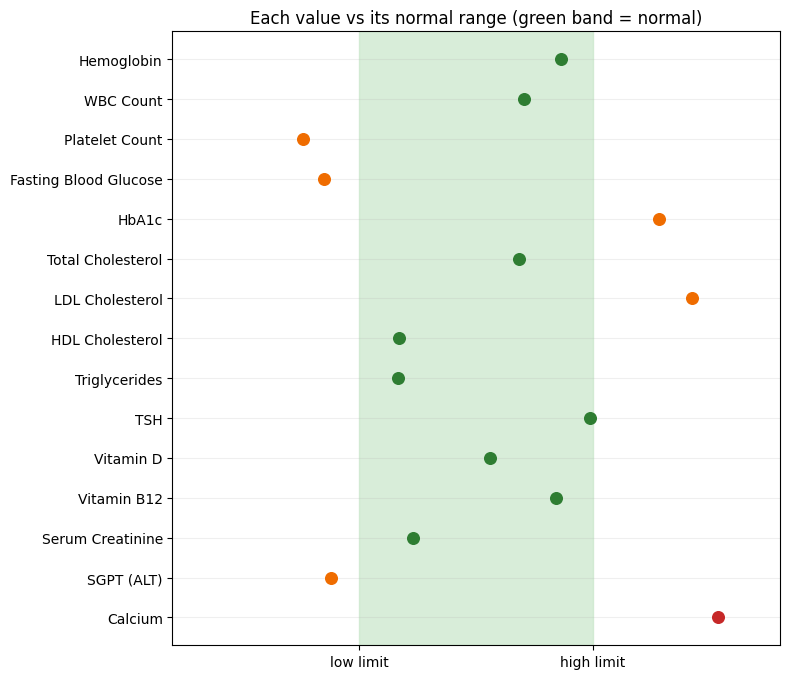

### Health risks
- **Platelet Count out of range** (moderate): Your Platelet Count (77.0 10^3/uL) is below the healthy reference range. Platelets help your blood clot; very low or high counts need medical attention.
- **Fasting Blood Glucose out of range** (moderate): Your Fasting Blood Glucose (65.64 mg/dL) is below the healthy reference range. Blood sugar after fasting; consistently high levels can indicate prediabetes/diabetes.
- **HbA1c out of range** (moderate): Your HbA1c (6.05 %) is above the healthy reference range. Reflects your average blood sugar over the last ~3 months.
- **LDL Cholesterol out of range** (moderate): Your LDL Cholesterol (121.2 mg/dL) is above the healthy reference range. 'Bad' cholesterol — high levels raise heart disease risk.
- **SGPT (ALT) out of range** (moderate): Your SGPT (ALT) (1.05 U/L) is below the healthy reference range. A liver enzyme; elevated levels can indicate liver stress or damage.
- **Calcium out of range** (severe): Your Calcium (11.21 mg/dL) is above the healthy reference range. Important for bones, muscles, and nerve function.

**🥗 Eat**
- Whole grains, fiber-rich vegetables
- Lean protein
- Low-glycemic-index foods
- High-fiber vegetables
- Oats, nuts, olive oil
- Fruits and vegetables

**🚫 Avoid**
- Refined sugar and sugary drinks
- White bread/rice in excess
- Sweets, sugary beverages
- Fried foods
- Trans fats / processed snacks

**🏃 Exercise**
- 30 minutes of brisk walking / cardio, 5 days a week (consult your doctor first).
- Post-meal 10-15 minute walks to help regulate blood sugar.

**💧 Hydration**
- Drink at least 2-3 liters of water daily unless advised otherwise.

**😴 Sleep**
- Aim for 7-8 hours of quality sleep each night, with a consistent bedtime.

**🧘 Stress**
- Practice 10 minutes of deep breathing, meditation, or yoga daily.
- Take regular breaks from screens and prioritize downtime.

**🌿 Lifestyle**
- Get a routine annual health check-up.
- Maintain a consistent sleep and wake schedule.
- Include at least 30 minutes of physical activity most days of the week.

In [37]:
import langchain_core.globals as g
g.get_debug = lambda: False
g.get_verbose = lambda: False
g.get_llm_cache = lambda: None

state = analyze_text(text)
show(state)

### What each agent produced
This is the shared `PipelineState` after the LangGraph run: one output per agent.

In [38]:
show_agents(state)

Agent 1 · Report Processing : 15 parameters | format: Thyroid panel | OCR confidence: 1.0 | warnings: 2
      ⚠ WBC Count: converted 8,930 cells/cumm -> 8.93 10^3/uL.
      ⚠ Platelet Count: converted 0.77 lakhs/cumm -> 77 10^3/uL.
Agent 2 · Medical Analysis  : 6 abnormal -> ['Platelet Count', 'Fasting Blood Glucose', 'HbA1c', 'LDL Cholesterol', 'SGPT (ALT)', 'Calcium'] | deficiencies: 0 | risks: 6
Agent 3 · Recommendations   : 20 recommendation items
Agent 4 · Report Generation : health score 50 | doctor consultation: True


## 5. Demo: messy real-world lab formats
`backend/tests_realistic/` has hand-written reports that imitate real lab layouts: a **technology column**, **SI units** (mmol/L, µmol/L, g/L), `cells/cumm`, `lakhs/cumm`, OCR-style typos, and ranges split across lines. Agent 1 converts units and classifies using the range **printed on the report**.

In [39]:
messy = open("backend/tests_realistic/r3_si_units.txt").read()
print(messy)

GENERAL HOSPITAL LABORATORY INFORMATION SYSTEM
PATIENT: DOE, JOHN     DOB: 14-MAR-1978     SEX: M
COLLECTED: 2025-09-10 06:50   RECEIVED: 2025-09-10 07:20

TEST                          RESULT   FLAG   UNITS       REF RANGE
Haemoglobin                   118      L      g/L         130 - 170
Glucose (fasting)             7.4      H      mmol/L      3.9 - 5.6
Cholesterol total             5.9      H      mmol/L      < 5.2
Triglycerides                 1.4             mmol/L      < 1.7
HDL cholesterol               1.1             mmol/L      > 1.0
Creatinine                    142      H      umol/L      62 - 106
Urea nitrogen                 9.8      H      mmol/L      2.5 - 7.8
Calcium                       2.31            mmol/L      2.10 - 2.55
Vitamin B12                   130      L      pmol/L      145 - 569
25-OH Vitamin D               48             nmol/L      50 - 125
TSH                           2.1             mIU/L       0.35 - 4.94



In [40]:
state2 = analyze_text(messy)
print("Values below are converted to standard units (e.g. glucose mmol/L -> mg/dL)\n")
rows = [{"Parameter": p.name, "Raw": p.raw_value, "Value (std)": p.value, "Unit": p.unit,
         "Reference": p.reference_range, "Status": p.status} for p in state2.extracted.parameters]
display(pd.DataFrame(rows).style.apply(_color, subset=["Status"]).hide(axis="index"))
for w in state2.extracted.warnings:
    print("⚠", w)

Values below are converted to standard units (e.g. glucose mmol/L -> mg/dL)



Parameter,Raw,Value (std),Unit,Reference,Status
Hemoglobin,118,11.800000,g/dL,13-17,low
Fasting Blood Glucose,7.4,133.318400,mg/dL,70.26-100.9,critical_high
Total Cholesterol,5.9,228.153000,mg/dL,<201.1,high
Triglycerides,1.4,123.998000,mg/dL,<150.6,normal
HDL Cholesterol,1.1,42.537000,mg/dL,>38.67,normal
Serum Creatinine,142,1.606300,mg/dL,0.7014-1.199,critical_high
Blood Urea Nitrogen,9.8,27.449800,mg/dL,7.003-21.85,high
Calcium,2.31,9.258500,mg/dL,8.417-10.22,normal
Vitamin B12,130,176.150000,pg/mL,196.5-771,low
Vitamin D,48,19.228800,ng/mL,20.03-50.08,low


⚠ Hemoglobin: converted 118 g/L -> 11.8 g/dL.
⚠ Fasting Blood Glucose: converted 7.4 mmol/L -> 133.3 mg/dL.
⚠ Total Cholesterol: converted 5.9 mmol/L -> 228.2 mg/dL.
⚠ Triglycerides: converted 1.4 mmol/L -> 124 mg/dL.
⚠ HDL Cholesterol: converted 1.1 mmol/L -> 42.54 mg/dL.
⚠ Serum Creatinine: converted 142 umol/L -> 1.606 mg/dL.
⚠ Blood Urea Nitrogen: converted 9.8 mmol/L -> 27.45 mg/dL.
⚠ Calcium: converted 2.31 mmol/L -> 9.258 mg/dL.
⚠ Vitamin B12: converted 130 pmol/L -> 176.2 pg/mL.
⚠ Vitamin D: converted 48 nmol/L -> 19.23 ng/mL.


## 6. Evaluation against ground truth
`scripts/evaluate.py` runs the pipeline on labelled reports and measures extraction recall, value accuracy, and low/normal/high accuracy.

> ⚠️ Both sets are **synthetic / hand-written**, so ~100% here does **not** mean 100% on real reports. Real-report validation is the next step.

In [41]:
print("=== 25 synthetic reports, 4 layouts ===")
!python backend/scripts/evaluate.py 2>/dev/null | head -9
print("\n=== 5 hand-written realistic formats ===")
!python backend/scripts/evaluate.py --dir backend/tests_realistic 2>/dev/null | head -9

=== 25 synthetic reports, 4 layouts ===

=== 5 hand-written realistic formats ===


## 7. (Optional) Try your own report
Tick the box and run the cell to upload a `.pdf`, `.png/.jpg`, `.docx` or `.txt`. **Use de-identified reports only** (remove name, ID, phone). Scanned images go through Tesseract OCR; if OCR confidence is below 85% the report shows a "please verify" warning.

In [42]:
#@title Upload a report { display-mode: "form" }
RUN_UPLOAD = False #@param {type:"boolean"}

if RUN_UPLOAD:
    from google.colab import files
    from app.ocr_extraction import extract_text_from_pdf, extract_text_from_image, extract_text_from_docx
    uploaded = files.upload()
    for fname, data in uploaded.items():
        ext = fname.lower().rsplit(".", 1)[-1]
        if ext == "pdf":
            txt, conf = extract_text_from_pdf(data)
        elif ext in ("png", "jpg", "jpeg"):
            txt, conf = extract_text_from_image(data)
        elif ext == "docx":
            txt, conf = extract_text_from_docx(data)
        else:
            txt, conf = data.decode("utf-8", errors="ignore"), 1.0
        print(f"{fname}: extracted {len(txt)} characters, OCR confidence {conf:.0%}")
        st = analyze_text(txt, file_type=ext, ocr_confidence=conf)
        for w in st.extracted.warnings:
            print("⚠", w)
        show(st)
else:
    print("Tick RUN_UPLOAD above, then run this cell again.")

Tick RUN_UPLOAD above, then run this cell again.


## 8. Summary and limitations

**Design choices**
- Extraction and flagging (Agent 1) are **deterministic and testable**. The LLM is only used for explanation and advice (Agents 2 and 3), with Pydantic-validated JSON and a rule-based fallback.
- A curated reference-range table (WHO / NIH / Mayo summaries) grounds the LLM prompts and is the fallback when a report has no printed range. It is a curated lookup, not a vector-search RAG.
- The range **printed on the report** is preferred over the table, because normal ranges depend on the lab, sex and age.

**Limitations (be honest)**
- Accuracy numbers are on synthetic / hand-written data, not real patient reports.
- Tesseract accuracy drops on blurry photos; a vision-LLM extractor would help.
- Sex/age-specific ranges are not yet taken from patient info when the report prints no range.
- Informational only, not a diagnosis.

**Next steps:** validate on de-identified real reports, add a Claude-vision extraction path for poor scans, more parameters, authentication for a public deployment.